In [24]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score
)

from xgboost import XGBClassifier

import joblib
import json

In [25]:
X_train = pd.read_csv("../data/final/X_train.csv")

X_test = pd.read_csv("../data/final/X_test.csv")

y_train = pd.read_csv("../data/final/y_train.csv").squeeze()

y_test = pd.read_csv("../data/final/y_test.csv").squeeze()

In [26]:
print(X_train.shape)

print(X_test.shape)

print(y_train.shape)

print(y_test.shape)

(432, 19)
(104, 19)
(432,)
(104,)


In [27]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [28]:
rf_preds = rf_model.predict(X_test)

rf_probs = rf_model.predict_proba(X_test)[:, 1]

In [29]:
print("Accuracy:", accuracy_score(y_test, rf_preds))

print("Precision:", precision_score(y_test, rf_preds))

print("Recall:", recall_score(y_test, rf_preds))

print("F1 Score:", f1_score(y_test, rf_preds))

print("ROC AUC:", roc_auc_score(y_test, rf_probs))

Accuracy: 0.6442307692307693
Precision: 0.660377358490566
Recall: 0.6481481481481481
F1 Score: 0.6542056074766355
ROC AUC: 0.7109259259259259


In [30]:
print(classification_report(y_test, rf_preds))

              precision    recall  f1-score   support

           0       0.63      0.64      0.63        50
           1       0.66      0.65      0.65        54

    accuracy                           0.64       104
   macro avg       0.64      0.64      0.64       104
weighted avg       0.64      0.64      0.64       104



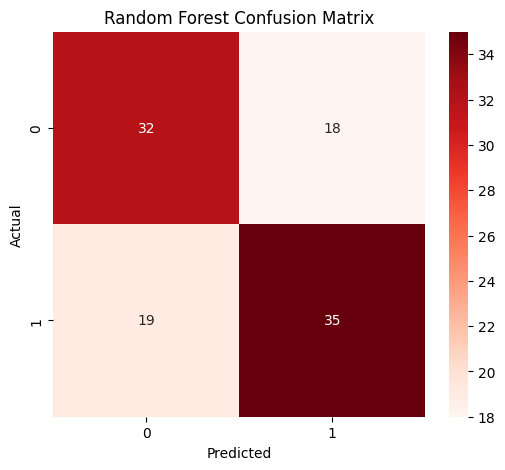

In [36]:
cm = confusion_matrix(y_test, rf_preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds"
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [32]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [33]:
xgb_preds = xgb_model.predict(X_test)

xgb_probs = xgb_model.predict_proba(X_test)[:,1]

In [34]:
print("Accuracy:", accuracy_score(y_test, xgb_preds))

print("Precision:", precision_score(y_test, xgb_preds))

print("Recall:", recall_score(y_test, xgb_preds))

print("F1 Score:", f1_score(y_test, xgb_preds))

print("ROC AUC:", roc_auc_score(y_test, xgb_probs))

Accuracy: 0.625
Precision: 0.6415094339622641
Recall: 0.6296296296296297
F1 Score: 0.6355140186915887
ROC AUC: 0.6811111111111111


In [35]:
print(classification_report(y_test, xgb_preds))

              precision    recall  f1-score   support

           0       0.61      0.62      0.61        50
           1       0.64      0.63      0.64        54

    accuracy                           0.62       104
   macro avg       0.62      0.62      0.62       104
weighted avg       0.63      0.62      0.63       104



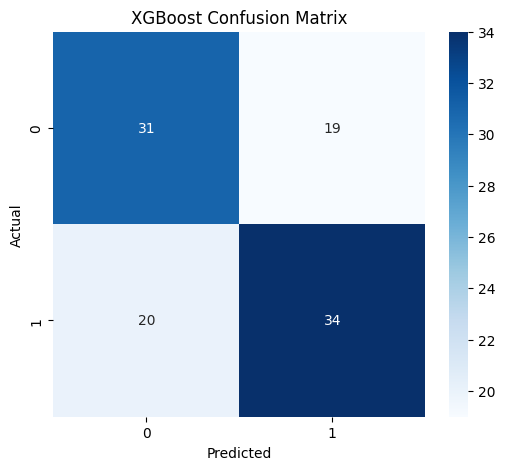

In [13]:
cm = confusion_matrix(y_test, xgb_preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("XGBoost Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

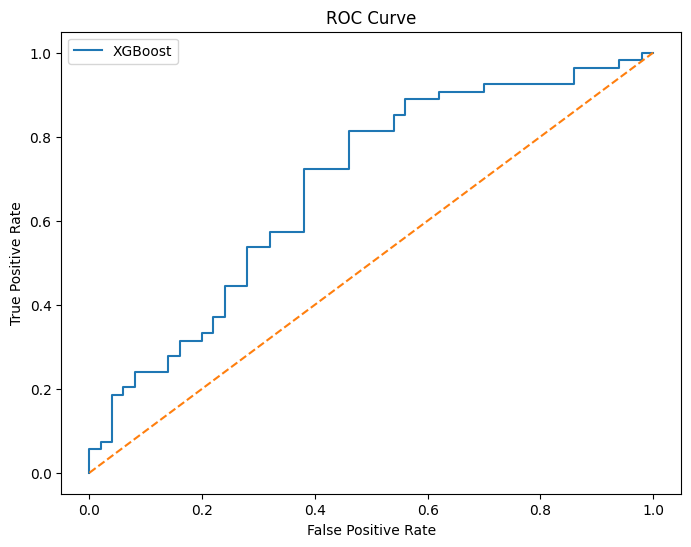

In [45]:
fpr, tpr, thresholds = roc_curve(y_test, xgb_probs)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label="XGBoost")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

# SAVE BEFORE SHOW
plt.savefig("../reports/roc_curve.png")

plt.show()

In [39]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
11,humidity_deficit,0.073235
6,temp,0.064604
14,vegetation_dryness,0.063490
18,month_cos,0.062214
12,no_rain,0.061470
1,Y,0.060957
0,X,0.060079
13,heat_stress,0.057410
7,RH,0.056617
15,month_num,0.055723


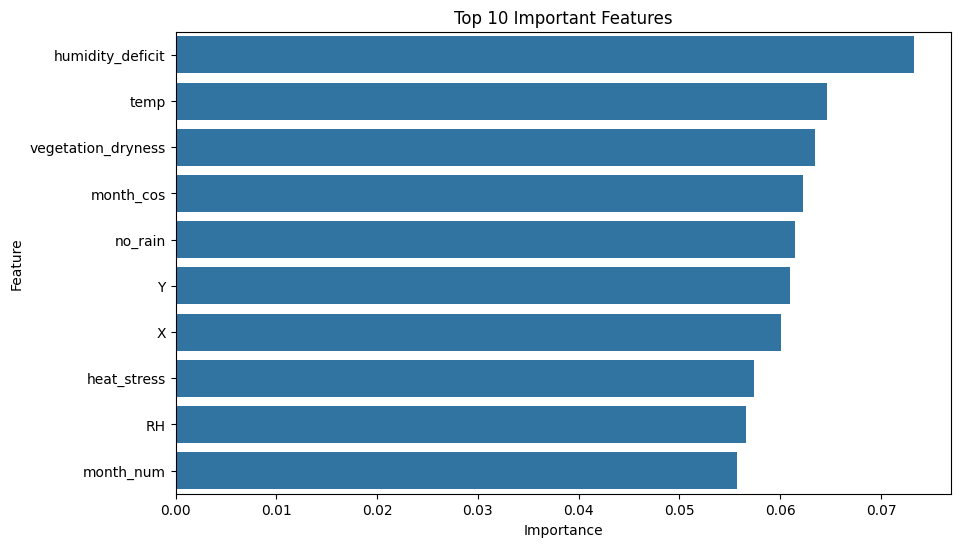

In [37]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance.head(10)
)

plt.title("Top 10 Important Features")

# Save FIRST
plt.savefig("../reports/feature_importance.png")

plt.show()

In [17]:
custom_threshold = 0.35

custom_preds = (xgb_probs >= custom_threshold).astype(int)

In [40]:
print("Precision:", precision_score(y_test, custom_preds))

print("Recall:", recall_score(y_test, custom_preds))

print("F1:", f1_score(y_test, custom_preds))

Precision: 0.640625
Recall: 0.7592592592592593
F1: 0.6949152542372882


In [41]:
joblib.dump(
    xgb_model,
    "../models/fire_model.pkl"
)

['../models/fire_model.pkl']

In [46]:
metadata = {
    "model": "XGBoost",
    "threshold": custom_threshold,
    "features": list(X_train.columns),
    "roc_auc": float(roc_auc_score(y_test, xgb_probs))
}

with open("../models/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

In [47]:
loaded_model = joblib.load("../models/fire_model.pkl")

sample_pred = loaded_model.predict(X_test.iloc[:5])

print(sample_pred)

[0 0 1 0 1]
